# Jia Long Bao (12593400)
MSc Information Studies: Data Science

Baselines currently have the regression task predictiong avg delay minutes per station, but might pivot to binary classification to align with prior work

In [1]:
# 1. Install necessary libraries
!pip install darts duckdb XGBoost LightGBM

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/

## Imports

First, let's import the necessities

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries
from darts.utils.statistics import check_seasonality, extract_trend_and_seasonality, stationarity_test_kpss, plot_acf, plot_residuals_analysis
import duckdb

# Define the base path
base_path = '/content/drive/MyDrive/Thesis_NS/full_dataset_partitioned'

# Load Train and Validation data using DuckDB
# We select all columns (*) from the parquet files and convert immediately to a Pandas DataFrame
df_train = duckdb.query(f"SELECT * FROM '{base_path}/data_train.parquet'").to_df()
df_val = duckdb.query(f"SELECT * FROM '{base_path}/data_val.parquet'").to_df()
df_test = duckdb.query(f"SELECT * FROM '{base_path}/data_test.parquet'").to_df()

# Inspect the data to ensure it loaded correctly
print("Train shape:", df_train.shape)
print(df_train.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train shape: (13920408, 27)
                   hour_bin station_code  hour_of_day  day_of_week  \
0 2019-03-06 12:00:00+00:00           MZ           13            3   
1 2019-03-06 12:00:00+00:00           NA           13            3   
2 2019-03-06 12:00:00+00:00          NDB           13            3   
3 2019-03-06 12:00:00+00:00           NH           13            3   
4 2019-03-06 12:00:00+00:00          NKK           13            3   

   month_of_year  total_trains  delayed_trains_count  total_delay_minutes  \
0              3             4                   1.0                  2.0   
1              3             0                   0.0                  0.0   
2              3            12                   4.0                 11.0   
3              3             0                   0.0                  0.0   
4              3             4                   2.0                  3.0   

   avg_delay_minutes  disruption_count  ...  snow_depth_m  is_precipitating  \
0        

In [4]:
query = f"""
SELECT * FROM '{base_path}/data_train.parquet'
UNION ALL
SELECT * FROM '{base_path}/data_val.parquet'
ORDER BY hour_bin  -- Optional: Sort by time immediately
"""

df_train = duckdb.query(query).to_df()

In [24]:
cols_to_drop = ['holiday_name', 'day_of_week_1', 'month_of_year_1', 'hour_of_day_1']

In [23]:
df_test = df_test.drop(columns=cols_to_drop)

In [ ]:
df_train = df_train.drop(columns=cols_to_drop)

## Preprocessing

### Creating timeseries object

exclude any non numbers from cov

In [25]:
from darts import TimeSeries

# Replace 'timestamp' with your actual time column name
# Replace 'target_variable' with the name of the column you want to predict
# If you want to forecast MULTIPLE targets, pass a list: value_cols=['sales', 'inventory']

# 1. Convert Train
series_train = TimeSeries.from_group_dataframe(
    df_train,
    time_col='hour_bin',
    value_cols=['avg_delay_minutes'], # The column(s) you want to predict
    fill_missing_dates=True,        # Optional: handles gaps in time
    freq='h',
    group_cols= 'station_code'
)

# 2. Convert Validation
series_test = TimeSeries.from_group_dataframe(
    df_test,
    time_col='hour_bin',
    value_cols=['avg_delay_minutes'],
    fill_missing_dates=True,
    freq='h',
    group_cols= 'station_code'
)

# 3. Handle Covariates (Multivariate Features)
# If your dataframe has other columns that help prediction, load them as covariates
# Example: Using all columns EXCEPT the target and time as past covariates
covariate_cols = [c for c in df_train.columns if c not in ['hour_bin', 'avg_delay_minutes', 'station_code', 'holiday_name', 'day_of_week_1', 'month_of_year_1', 'hour_of_day_1']]
future_covs_cols = ['hour_of_day', 'day_of_week', 'month_of_year', 'is_holiday', 'is_weekend', 'is_rush_hour']
past_covs_cols = [c for c in covariate_cols if c not in future_covs_cols]

future_cov_train = TimeSeries.from_group_dataframe(df_train, time_col='hour_bin', value_cols=future_covs_cols, group_cols= 'station_code')
past_cov_train = TimeSeries.from_group_dataframe(df_train, time_col='hour_bin', value_cols=past_covs_cols, group_cols= 'station_code')
future_cov_test = TimeSeries.from_group_dataframe(df_test, time_col='hour_bin', value_cols=future_covs_cols, group_cols='station_code')
past_cov_test = TimeSeries.from_group_dataframe(df_test, time_col='hour_bin', value_cols=past_covs_cols, group_cols='station_code')

## (Mini) EDA

For visualization purposes and to see higher level trends, we perform the EDA on a the whole network instead of individual station level

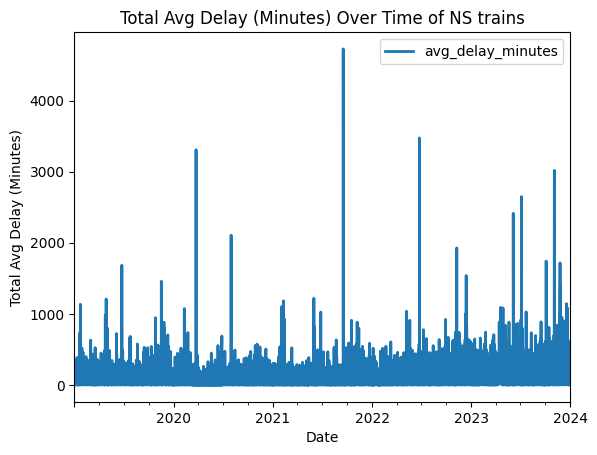

In [ ]:
# Aggregate avg delays by date (sum of sales for avg delays on the same date)
df_aggregated = df_train.groupby('hour_bin')['avg_delay_minutes'].sum().reset_index()

# Create a TimeSeries from the aggregated DataFrame
total_delay_series = TimeSeries.from_dataframe(df_aggregated, time_col='hour_bin', value_cols='avg_delay_minutes')

# Plot the aggregated delay
total_delay_series.plot();
plt.title("Total Avg Delay (Minutes) Over Time of NS trains")
plt.xlabel("Date")
plt.ylabel("Total Avg Delay (Minutes)")
plt.show()

We see slight upward trend and a seasonality. In addition there's seem to be two somewhat concentrated peaks each year. There is also an outlier peak near Q3 2021, after further investigation we concluded that this might be covid related (https://2022.nsjaarverslag.nl/jaarverslag-2021/over-ns/ns-en-corona-in-2021)

### Seasonality

In [ ]:
seasonality = check_seasonality(total_delay_series)
seasonality

(True, np.int64(12))

Has a seasonality period of 12

In [6]:
nlags = 12

### Stationary

In [ ]:
stationarity_test_kpss(total_delay_series, nlags=nlags)

/usr/local/lib/python3.12/dist-packages/darts/utils/statistics.py:484: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


(np.float64(56.28636927580046),
 np.float64(0.01),
 12,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

p < 0.01, we reject the null hypothesis of stationarity. This suggests that the time series is non-stationary, and might need to apply techniques such as differencing or transformation to make it stationary before proceeding with further time series modeling (e.g., ARIMA).

### ACF

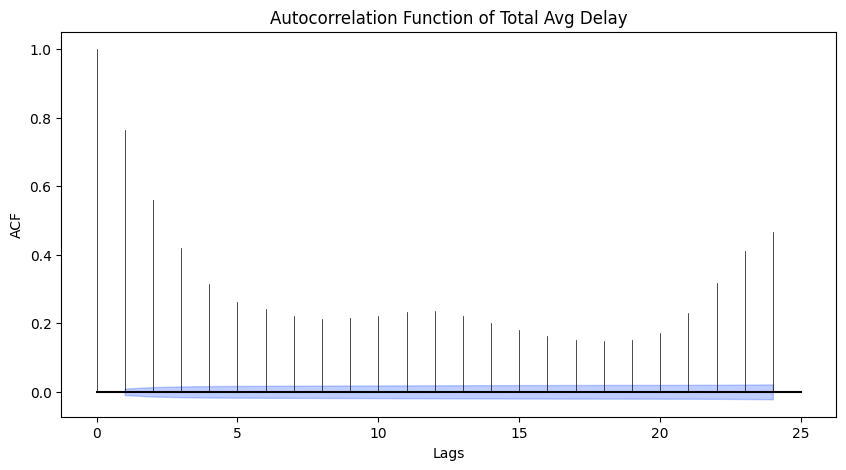

In [ ]:
plot_acf(total_delay_series)

plt.title("Autocorrelation Function of Total Avg Delay")
plt.xlabel("Lags")
plt.ylabel("ACF")

plt.show()

Shows high significant correlation at lag 24, showing strong daily seasonality. Bars decrease at the beginning (left), but rises back again when approaching 24 hours (right).

# Models

Scale variables, distinguish covariates

todo add node info as static cov? (station type, station connections)

In [31]:
from darts.dataprocessing.transformers import StaticCovariatesTransformer, Scaler

# --- PART 1: Handle Static Covariates ---
static_transformer = StaticCovariatesTransformer()

# Fit on TRAIN, Transform on BOTH
series_train = static_transformer.fit_transform(series_train)
series_test = static_transformer.transform(series_test)


# --- PART 2: Handle Dynamic Data (Target, Time-varying Covariates) ---
target_scaler = Scaler()
past_cov_scaler = Scaler()
future_cov_scaler = Scaler()

# Fit on TRAIN
series_train_scaled = target_scaler.fit_transform(series_train)
past_cov_train_scaled = past_cov_scaler.fit_transform(past_cov_train)
future_cov_train_scaled = future_cov_scaler.fit_transform(future_cov_train)

# Transform TEST (using the logic learned from Train)
series_test_scaled = target_scaler.transform(series_test)
past_cov_test_scaled = past_cov_scaler.transform(past_cov_test)
future_cov_test_scaled = future_cov_scaler.transform(future_cov_test)

Train Models

TODO uncomment to add builtin cyclic encoders

In [32]:
from darts.models import GlobalNaiveSeasonal, RandomForest, XGBModel, LightGBMModel, GlobalNaiveSeasonal

forecasts = {}

seasonality_period = 24

input_chunk_length = seasonality_period * 2
output_chunk_length = seasonality_period

random_state = 8

xgb_model = XGBModel(lags=seasonality_period, random_state = random_state)
lgbm_model = LightGBMModel(lags=seasonality_period,random_state = random_state)

# 1. XGBoost with Covariates
xgb_model = XGBModel(
    lags=seasonality_period,
    lags_past_covariates=seasonality_period,
    output_chunk_length=1,
    random_state=random_state,
    # add_encoders= {
    #     'cyclic': {'future': ['hour', 'dayofweek', 'month']}
    # }
)

# 2. LightGBM with Covariates
lgbm_model = LightGBMModel(
    lags=seasonality_period,
    lags_past_covariates=seasonality_period,
    output_chunk_length=1,
    random_state=random_state
    # add_encoders= {
    #     'cyclic': {'future': ['hour', 'dayofweek', 'month']}
    # }
)

# 3. Naive Seasonal (Does not use covariates)
# K=24 means "repeat the value from 24 hours ago"
pl_trainer_kwargs = {
    "accelerator": "auto",
    "precision": "32-true"  # Use standard 32-bit float
}

naive_model = GlobalNaiveSeasonal(input_chunk_length=input_chunk_length, output_chunk_length=output_chunk_length, pl_trainer_kwargs = pl_trainer_kwargs)

TODO rerun on snellius

In [ ]:
# Fit Naive
naive_model.fit(series_train_scaled)

# Fit XGBoost (Pass the covariates here)
print("Fitting XGBoost...")
xgb_model.fit(series=series_train_scaled,
              past_covariates=past_cov_train_scaled,
              # future_covariates=future_cov_train_scaled
              )

# Fit LightGBM
print("Fitting LightGBM...")
lgbm_model.fit(series=series_train_scaled,
              past_covariates=past_cov_train_scaled,
              # future_covariates=future_cov_train_scaled
               )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: True, using: 1 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Fitting XGBoost...


# OLD ignore below from prev my course

In [ ]:
from darts.models import GlobalNaiveSeasonal, RandomForest, XGBModel, LightGBMModel

forecasts = {}

seasonality_period = 24

input_chunk_length = seasonality_period * 2
output_chunk_length = seasonality_period

random_state = 8

xgb_model = XGBModel(lags=seasonality_period, random_state = random_state)
lgbm_model = LightGBMModel(lags=seasonality_period,random_state = random_state)
naive_model = GlobalNaiveSeasonal(input_chunk_length=input_chunk_length, output_chunk_length=output_chunk_length)

naive_model.fit(df_train)
xgb_model.fit(series_train)
lgbm_model.fit(series_train)


naive_forecast = [naive_model.predict(28, series=ts) for ts in series_train]
xgb_forecast = [xgb_model.predict(28, series=ts) for ts in series_train]
lgbm_forecast = [lgbm_model.predict(28, series=ts) for ts in series_train]


submission_naive = pd.DataFrame()
submission_xgb = pd.DataFrame()
submission_lgbm = pd.DataFrame()


for i, ts in enumerate(series_train):
    product_id = ts.static_covariates['id']

    naive_values = np.round(naive_forecast[i].values().flatten()).astype(int)
    xgb_values = np.round(xgb_forecast[i].values().flatten()).astype(int)
    lgbm_values = np.round(lgbm_forecast[i].values().flatten()).astype(int)

    submission_naive = pd.concat([
        submission_naive,
        pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(naive_values)}})
    ])
    submission_xgb = pd.concat([
        submission_xgb,
        pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(xgb_values)}})
    ])
    submission_lgbm = pd.concat([
        submission_lgbm,
        pd.DataFrame({'id': product_id, **{f"F{i+1}": val for i, val in enumerate(lgbm_values)}})
    ])


submission_naive.to_csv('submission_naive.csv', index=False)
submission_xgb.to_csv('submission_xgb.csv', index=False)
submission_lgbm.to_csv('submission_lgbm.csv', index=False)

KeyError: 0

#Prediction Visualization

Real sales date range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00
Last real sales date: 2016-04-24 00:00:00


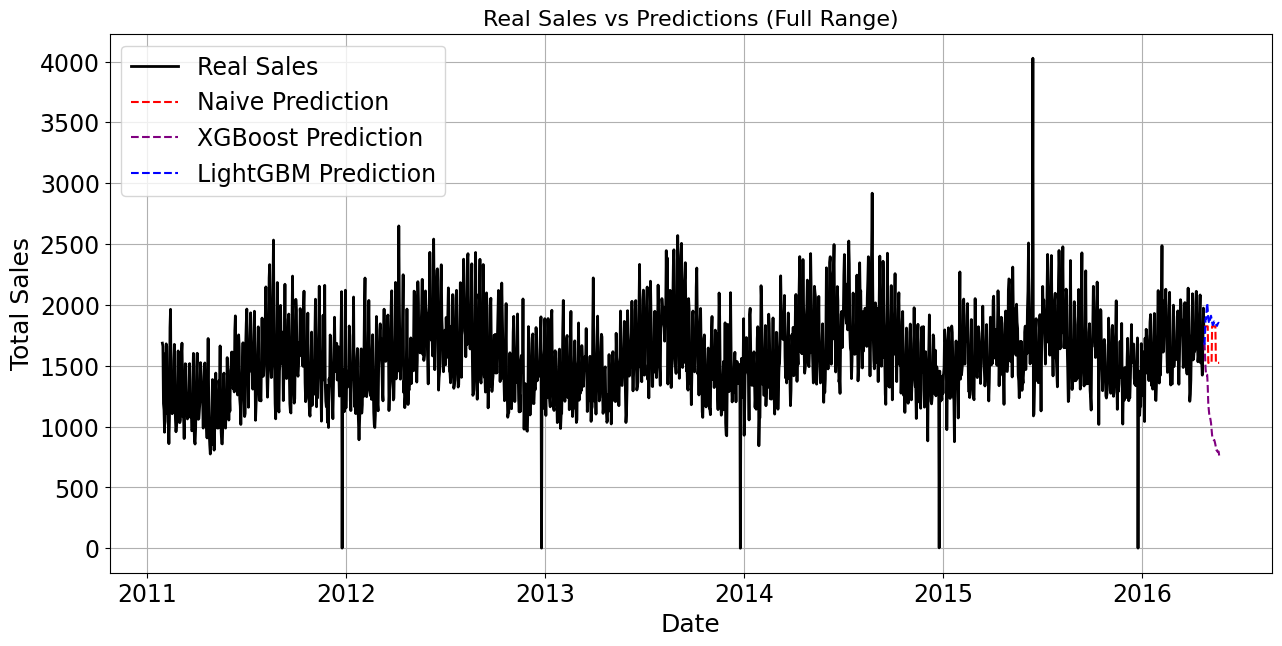

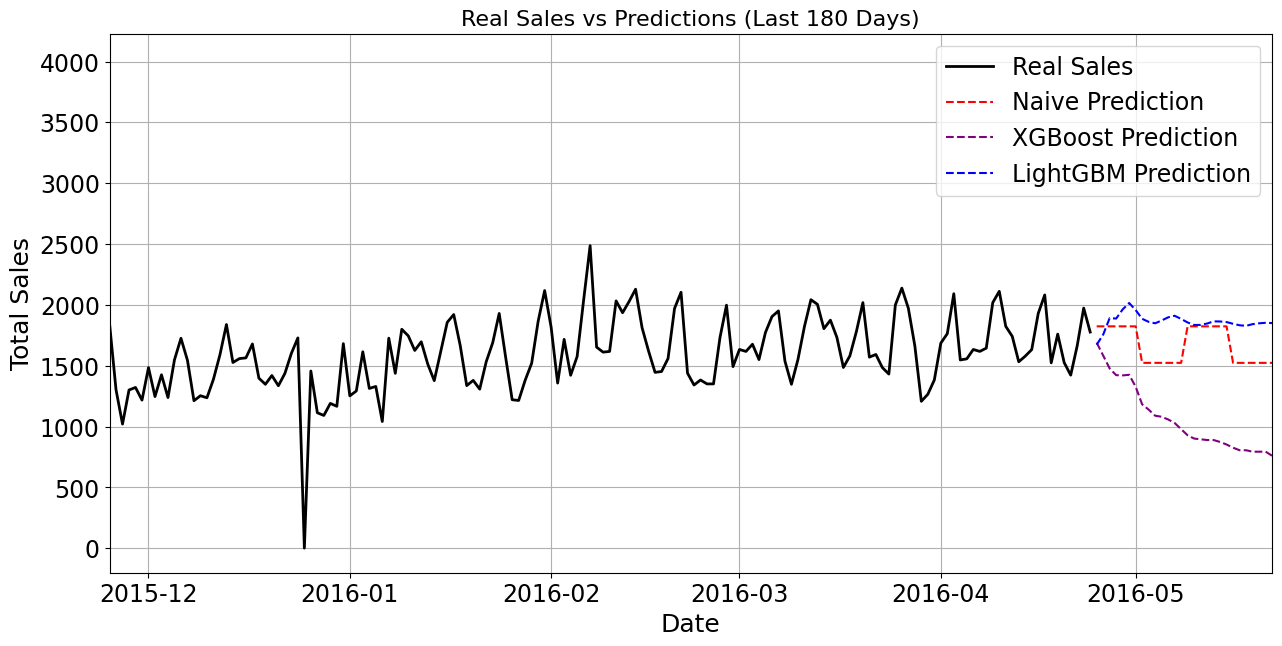

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


real_sales = sales_train_long.groupby('date')['sales'].sum().sort_index()
print("Real sales date range:", real_sales.index.min(), "to", real_sales.index.max())
last_real_date = real_sales.index[-1]
print("Last real sales date:", last_real_date)


prediction_dates = pd.date_range(start=last_real_date + pd.Timedelta(days=1), periods=28)

def convert_submission_to_daily(submission_df, prediction_dates):

    pred_long = submission_df.melt(id_vars='id', var_name='F', value_name='pred_sales')

    pred_long['day_offset'] = pred_long['F'].str.extract(r'(\d+)').astype(int)

    pred_long['date'] = prediction_dates[pred_long['day_offset'] - 1].values

    daily_pred = pred_long.groupby('date')['pred_sales'].sum().reset_index()
    return daily_pred


naive_daily = convert_submission_to_daily(submission_naive, prediction_dates)
xgb_daily = convert_submission_to_daily(submission_xgb, prediction_dates)
lgbm_daily = convert_submission_to_daily(submission_lgbm, prediction_dates)


actual_daily = real_sales.reset_index().rename(columns={'sales': 'actual_sales'})


compare_df = actual_daily.merge(naive_daily, on='date', how='outer', suffixes=('', '_naive'))
compare_df = compare_df.merge(xgb_daily, on='date', how='outer', suffixes=('', '_xgb'))
compare_df = compare_df.merge(lgbm_daily, on='date', how='outer', suffixes=('', '_lgbm'))


compare_df.rename(columns={'pred_sales': 'naive_pred',
                           'pred_sales_xgb': 'xgb_pred',
                           'pred_sales_lgbm': 'lgbm_pred'}, inplace=True)



plt.figure(figsize=(15, 7))
plt.plot(compare_df['date'], compare_df['actual_sales'], label="Real Sales", color='black', linewidth=2)
plt.plot(compare_df['date'], compare_df['naive_pred'], label="Naive Prediction", color='red', linestyle='--')
plt.plot(compare_df['date'], compare_df['xgb_pred'], label="XGBoost Prediction", color='purple', linestyle='--')
plt.plot(compare_df['date'], compare_df['lgbm_pred'], label="LightGBM Prediction", color='blue', linestyle='--')

plt.title("Real Sales vs Predictions (Full Range)", fontsize=16)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Total Sales", fontsize=18)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.legend(fontsize=17)
plt.grid(True)
plt.show()



if len(compare_df) > 180:
    plt.figure(figsize=(15, 7))
    plt.plot(compare_df['date'], compare_df['actual_sales'], label="Real Sales", color='black', linewidth=2)
    plt.plot(compare_df['date'], compare_df['naive_pred'], label="Naive Prediction", color='red', linestyle='--')
    plt.plot(compare_df['date'], compare_df['xgb_pred'], label="XGBoost Prediction", color='purple', linestyle='--')
    plt.plot(compare_df['date'], compare_df['lgbm_pred'], label="LightGBM Prediction", color='blue', linestyle='--')

    plt.title("Real Sales vs Predictions (Last 180 Days)", fontsize=16)
    plt.xlabel("Date", fontsize=18)
    plt.ylabel("Total Sales", fontsize=18)
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    plt.legend(fontsize=17)
    plt.grid(True)


    plt.xlim([compare_df['date'].iloc[-180], compare_df['date'].max()])

    plt.show()



# Residual distribution

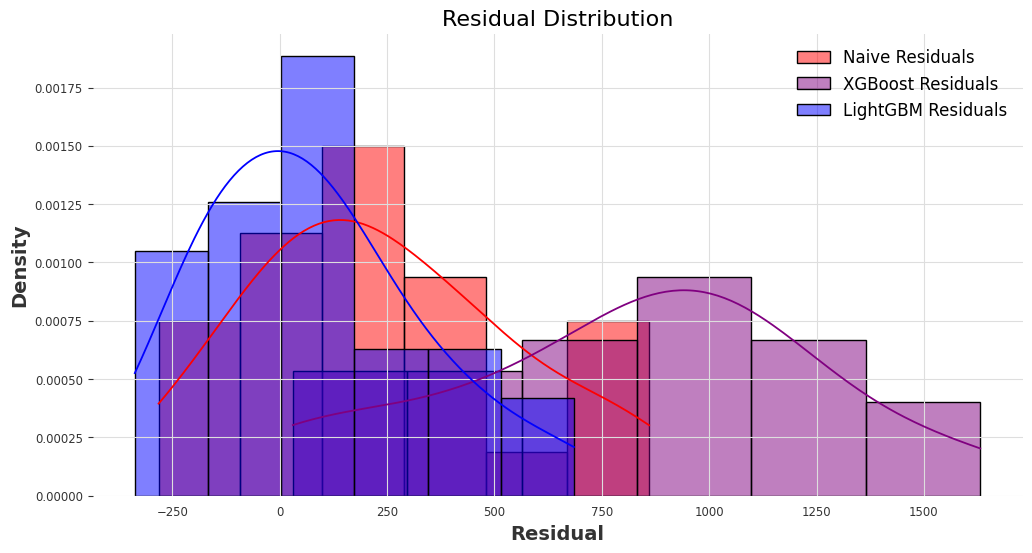

In [ ]:
# import seaborn as sns

# real_sales = sales_test_long.groupby('date')['sales'].sum().reset_index()
# real_sales.rename(columns={'sales': 'actual_sales'}, inplace=True)

# naive_daily = naive_forecast_all.groupby('date')['naive_pred'].sum().reset_index()
# xgb_daily = xgb_forecast_all.groupby('date')['xgb_pred'].sum().reset_index()
# lgbm_daily = lgbm_forecast_all.groupby('date')['lgbm_pred'].sum().reset_index()

# compare_df = real_sales.merge(naive_daily, on='date', how='outer') \
#     .merge(xgb_daily, on='date', how='outer') \
#     .merge(lgbm_daily, on='date', how='outer')


# compare_df['naive_residual'] = compare_df['actual_sales'] - compare_df['naive_pred']
# compare_df['xgb_residual'] = compare_df['actual_sales'] - compare_df['xgb_pred']
# compare_df['lgbm_residual'] = compare_df['actual_sales'] - compare_df['lgbm_pred']


# plt.figure(figsize=(12, 6))
# sns.histplot(clean_residuals['naive_residual'], label='Naive Residuals', color='red', kde=True, stat='density', alpha=0.5)
# sns.histplot(clean_residuals['xgb_residual'], label='XGBoost Residuals', color='purple', kde=True, stat='density', alpha=0.5)
# sns.histplot(clean_residuals['lgbm_residual'], label='LightGBM Residuals', color='blue', kde=True, stat='density', alpha=0.5)
# plt.title('Residual Distribution', fontsize=16)
# plt.xlabel('Residual', fontsize=14)
# plt.ylabel('Density', fontsize=14)
# plt.legend(fontsize=12)
# plt.grid(True)
# plt.show()

# Metrics

In [ ]:
from darts.metrics.metrics import rmse, mae, rmsle


# Calculate metrics for each model
metrics_data = {
    "Metric": ["RMSE", "MAE", "RMSLE"],
    "Naive Model": [
        np.mean(rmse(actual_series, naive_forecast)),
        np.mean(mae(actual_series, naive_forecast)),
        np.mean(rmsle(actual_series, naive_forecast))
    ],
    "XGB Model": [
        np.mean(rmse(actual_series, xgb_forecast)),
        np.mean(mae(actual_series, xgb_forecast)),
        np.mean(rmsle(actual_series, xgb_forecast))
    ],
    "LGBM Model": [
        np.mean(rmse(actual_series, lgbm_forecast)),
        np.mean(mae(actual_series, lgbm_forecast)),
        np.mean(rmsle(actual_series, lgbm_forecast))
    ]
}

# Create a DataFrame for the metrics
metrics_table = pd.DataFrame(metrics_data)

# Display the metrics table
metrics_table

,Metric,Naive Model,XGB Model,LGBM Model
0,RMSE,2.303771,2.162596,2.031336
1,MAE,1.734768,1.584508,1.602213
2,RMSLE,0.664816,0.645280,0.623258
